In [1]:
#프로젝트: ResNet Ablation Study

In [2]:
# Pytorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Helper libraries\
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# 데이터셋 로드
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train = True, download = True, transform = transform)
testset = torchvision.datasets.CIFAR10(root=',/data', train = False, download = True, transform = transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size = 32, shuffle = True)
testloader = torch.utils.data.DataLoader(testset, batch_size = 32, shuffle = False)

100%|██████████| 170M/170M [00:13<00:00, 12.3MB/s]
100%|██████████| 170M/170M [00:12<00:00, 13.2MB/s]


In [4]:
#이미지의 표현이 0과 1 사이로 들어오도록 정규화

transform = transforms.Compose([
    transforms.ToTensor()
])

In [5]:
#VGG Block 만들기

def build_vgg_block(input_layer,
                    num_cnn = 3,
                    channel = 64,
                    block_num =1):
  #입력 레이어
  x = input_layer

  #CNN 레이어
  layers = []
  in_channels = x.size(1)
  for cnn_num in range(num_cnn):
      layers.append(
          nn.Conv2d(
              in_channels=in_channels,
              out_channels=channel,
              kernel_size = 3,
              stride = 1,
              padding =1,
          )
      )
      layers.append(nn.ReLU(inplace = True))
      in_channels = channel

  #Max Pooling 레이어
  layers.append(
      nn.MaxPool2d(
          kernel_size = 2,
          stride =2
      )
  )

  #Sequential으로 레이어 묶기
  block = nn.Sequential(*layers)
  return block

In [6]:
class VGGNet(nn.Module):
    def __init__(self):
        super(VGGNet, self).__init__()

        #VGG 블록 생성
        self.vgg_block = build_vgg_block(torch.zeros(1, 3, 32, 32))

    def forward(self, x):
        return self.vgg_block(x)

In [7]:
#블록 1개짜리 model 생성
model = VGGNet()
print(model)

dummy_input = torch.zeros(1, 3, 32, 32)
output = model(dummy_input)
print(output.shape)

VGGNet(
  (vgg_block): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
)
torch.Size([1, 64, 16, 16])


In [8]:
#VGG 모델 설계 클래스
class VGG(nn.Module):
    def __init__(self, num_cnn_list = [2, 2, 3, 3, 3], channel_list = [64, 128, 256, 512, 512], num_classes = 10):
        super(VGG, self).__init__()
        assert len(num_cnn_list) == len(channel_list),  "num_cnn_list와 channel_list의 길이가 일치해야함"

        layers = []
        in_channels = 3

        for num_cnn, out_channels in zip(num_cnn_list, channel_list):
            layers.append(self._make_vgg_block(in_channels, out_channels, num_cnn))
            in_channels = out_channels

        self.feature_extractor = nn.Sequential(*layers)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 1 * 1, 4096),
            nn.ReLU(True),
            nn.Linear(4096, 4096),
            nn.ReLU(True),
            nn.Linear(4096, num_classes)
        )

    def _make_vgg_block(self, in_channels, out_channels, num_cnn):
        layers = [nn.Conv2d(in_channels, out_channels, kernel_size = 3, padding = 1), nn.ReLU(True)]
        for _ in range(num_cnn - 1):
            layers.append(nn.Conv2d(out_channels, out_channels, kernel_size = 3, padding = 1))
            layers.append(nn.ReLU(True))
        layers.append(nn.MaxPool2d(kernel_size = 2, stride =2))   #Max Pooling 추가
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.classifier(x)
        return x

In [9]:
#기본값을 그대로 사용하여 VGG 모델을 만들면 VGG-16이 됨
vgg_16 = VGG()
print(vgg_16)

VGG(
  (feature_extractor): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), pa

In [10]:
#원하는 블록의 설계에 따라 매개변수로 리스트 전달
#VGG-19
vgg_19 = VGG(
    num_cnn_list = [2, 2, 4, 4, 4],
    channel_list = [64, 128, 256, 512, 512]
)
print(vgg_19)

VGG(
  (feature_extractor): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), pa

In [11]:
#VGG-13
def build_vgg13(num_classes=10):
    return VGG(
        num_cnn_list=[2, 2, 2, 2, 2],
        channel_list=[64, 128, 256, 512, 512],
        num_classes=num_classes
    )

In [12]:
vgg_13 = build_vgg13()
print(vgg_13)

VGG(
  (feature_extractor): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation

In [13]:
#VGG-16과 VGG-19 비교
BATCH_SIZE = 256
EPOCH = 15

In [14]:
#CIFAR-10 데이터셋에 대해 Normalize와 Tensor 변환을 적용하는 코드
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225])
])

trainset = torchvision.datasets.CIFAR10(root = './data', train=True, download = True, transform = transform)
testset = torchvision.datasets.CIFAR10(root = './data', train = False, download = True, transform = transform)

trainloader = DataLoader(trainset, batch_size = BATCH_SIZE, shuffle = True)
testloader = DataLoader(testset, batch_size = BATCH_SIZE, shuffle = False)

In [19]:
#VGG-16 모델을 만들고 훈련
import time

current_time = time.time()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vgg_16 = torchvision.models.vgg16(pretrained = True)
vgg_16.to(device)

for param in vgg_16.parameters():
    param.requires_grad = True
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(vgg_16.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

vgg_16_train_losses = []
vgg_16_val_accuracy =[]

for epoch in range(EPOCH):
    vgg_16.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(trainloader, 0):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = vgg_16(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if i % 100 == 99:
            print(f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / (i+1):.3f}")

    train_loss = running_loss / len(trainloader)
    train_acc = 100 * correct / total
    vgg_16_train_losses.append(train_loss)

    print(f"Epoch {epoch + 1}: Train Accuracy: {train_acc:.2f}%")

    vgg_16.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = vgg_16(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    vgg_16_val_accuracy.append(val_acc)

    print(f"Epoch {epoch + 1}: Validation Accuracy: {val_acc:.2f}%")

print("Finished Training")
print(time.time() - current_time)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 76.7MB/s]


[1,   100] loss: 2.965
Epoch 1: Train Accuracy: 38.38%
Epoch 1: Validation Accuracy: 64.57%
[2,   100] loss: 0.938
Epoch 2: Train Accuracy: 69.98%
Epoch 2: Validation Accuracy: 74.96%
[3,   100] loss: 0.663
Epoch 3: Train Accuracy: 78.06%
Epoch 3: Validation Accuracy: 78.11%
[4,   100] loss: 0.551
Epoch 4: Train Accuracy: 81.59%
Epoch 4: Validation Accuracy: 81.13%
[5,   100] loss: 0.474
Epoch 5: Train Accuracy: 84.13%
Epoch 5: Validation Accuracy: 81.42%
[6,   100] loss: 0.411
Epoch 6: Train Accuracy: 86.25%
Epoch 6: Validation Accuracy: 83.02%
[7,   100] loss: 0.351
Epoch 7: Train Accuracy: 88.07%
Epoch 7: Validation Accuracy: 81.65%
[8,   100] loss: 0.310
Epoch 8: Train Accuracy: 89.57%
Epoch 8: Validation Accuracy: 82.96%
[9,   100] loss: 0.259
Epoch 9: Train Accuracy: 90.76%
Epoch 9: Validation Accuracy: 83.52%
[10,   100] loss: 0.233
Epoch 10: Train Accuracy: 91.99%
Epoch 10: Validation Accuracy: 84.39%
[11,   100] loss: 0.195
Epoch 11: Train Accuracy: 93.40%
Epoch 11: Validation

In [20]:
#VGG-19 모델을 만들고 훈련
current_time = time.time()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vgg_19 = torchvision.models.vgg19(pretrained=True)
vgg_19.to(device)

for param in vgg_19.parameters():
    param.requires_grad = True
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(vgg_19.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

vgg_19_train_losses = []
vgg_19_val_accuracy = []

for epoch in range(EPOCH):
    vgg_19.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(trainloader, 0):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = vgg_19(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if i % 100 == 99:
            print(f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / (i+1):.3f}")

    train_loss = running_loss / len(trainloader)
    vgg_19_train_losses.append(train_loss)

    train_acc = 100 * correct / total
    print(f"Epoch {epoch + 1}: Train Accuracy: {train_acc:.2f}%")

    vgg_19.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = vgg_19(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    vgg_19_val_accuracy.append(val_acc)

    print(f"Epoch {epoch + 1}: Validation Accuracy: {val_acc:.2f}%")

print("Finished Training")
print(time.time() - current_time)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:07<00:00, 78.1MB/s]


[1,   100] loss: 2.725
Epoch 1: Train Accuracy: 42.91%
Epoch 1: Validation Accuracy: 68.58%
[2,   100] loss: 0.816
Epoch 2: Train Accuracy: 74.12%
Epoch 2: Validation Accuracy: 78.06%
[3,   100] loss: 0.590
Epoch 3: Train Accuracy: 80.96%
Epoch 3: Validation Accuracy: 81.29%
[4,   100] loss: 0.475
Epoch 4: Train Accuracy: 84.11%
Epoch 4: Validation Accuracy: 82.51%
[5,   100] loss: 0.403
Epoch 5: Train Accuracy: 86.23%
Epoch 5: Validation Accuracy: 84.31%
[6,   100] loss: 0.345
Epoch 6: Train Accuracy: 88.24%
Epoch 6: Validation Accuracy: 84.24%
[7,   100] loss: 0.301
Epoch 7: Train Accuracy: 89.63%
Epoch 7: Validation Accuracy: 85.31%
[8,   100] loss: 0.261
Epoch 8: Train Accuracy: 91.12%
Epoch 8: Validation Accuracy: 85.73%
[9,   100] loss: 0.220
Epoch 9: Train Accuracy: 92.33%
Epoch 9: Validation Accuracy: 85.56%
[10,   100] loss: 0.187
Epoch 10: Train Accuracy: 93.77%
Epoch 10: Validation Accuracy: 85.89%
[11,   100] loss: 0.158
Epoch 11: Train Accuracy: 94.61%
Epoch 11: Validation

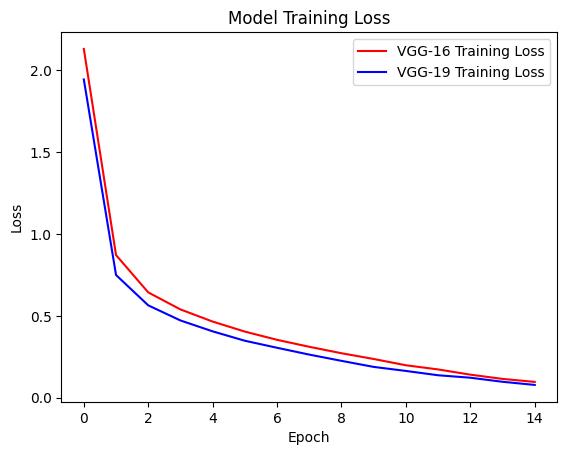

In [21]:
#그래프를 통해 training loss 비교
import matplotlib.pyplot as plt

plt.plot(vgg_16_train_losses, 'r', label = "VGG-16 Training Loss")
plt.plot(vgg_19_train_losses, 'b', label = "VGG-19 Training Loss")

plt.title("Model Training Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(loc = 'best')
plt.show()

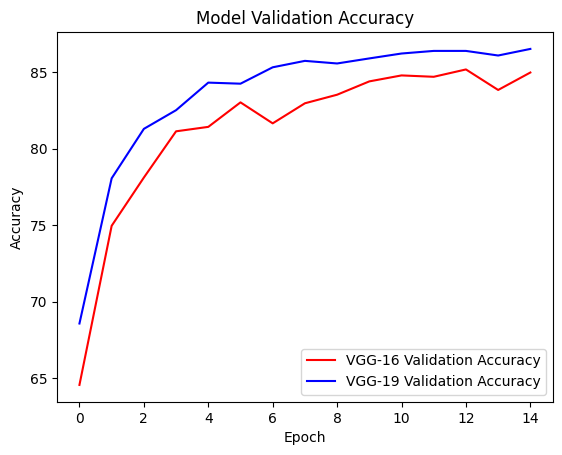

In [22]:
#그래프를 통해 validation accuracy 비교
plt.plot(vgg_16_val_accuracy, 'r', label = "VGG-16 Validation Accuracy")
plt.plot(vgg_19_val_accuracy, 'b', label = "VGG-19 Validation Accuracy")

plt.title("Model Validation Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(loc = "best")
plt.show()